## Setup

First, let's import the required libraries:

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lorenz_phase_space.phase_diagrams import Visualizer

# Set display options
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

## 1. Loading Real Cyclone Data

Let's load real cyclone data from the sample files:

In [2]:
# Load real cyclone data from samples
sample1_path = '../samples/sample_results_1.csv'
sample2_path = '../samples/sample_results_2.csv'

# Read the data
data = pd.read_csv(sample1_path)
data['Datetime'] = pd.to_datetime(data['Date'] + ' ' + data['Hour'].astype(str), format='%Y-%m-%d %H')

data2 = pd.read_csv(sample2_path)
data2['Datetime'] = pd.to_datetime(data2['Date'] + ' ' + data2['Hour'].astype(str), format='%Y-%m-%d %H')

print("Sample 1 data loaded:")
print(data[['Datetime', 'Ck', 'Ca', 'Ge', 'Ke']].head())
print(f"\nData shape: {data.shape}")
print(f"\nDate range: {data['Datetime'].min()} to {data['Datetime'].max()}")

print("\n" + "="*60)
print("Sample 2 data loaded:")
print(data2[['Datetime', 'Ck', 'Ca', 'Ge', 'Ke']].head())
print(f"\nData shape: {data2.shape}")
print(f"\nDate range: {data2['Datetime'].min()} to {data2['Datetime'].max()}")

Sample 1 data loaded:
             Datetime        Ck        Ca        Ge             Ke
0 2005-08-08 00:00:00 -4.531493  1.226199 -2.025434  259417.299960
1 2005-08-08 06:00:00 -5.264497  1.005979  0.496608  322462.033830
2 2005-08-08 12:00:00 -5.765075  1.003416  1.140691  350973.921520
3 2005-08-08 18:00:00 -6.444882  1.792113 -2.119746  434470.342917
4 2005-08-09 00:00:00 -7.594396  1.007388  1.165910  505485.268355

Data shape: (32, 26)

Date range: 2005-08-08 00:00:00 to 2005-08-15 18:00:00

Sample 2 data loaded:
             Datetime        Ck        Ca        Ge             Ke
0 1982-10-11 07:00:00 -3.068172  0.084163 -0.652870  144695.966067
1 1982-10-11 08:00:00 -3.293968 -0.007535 -0.339128  144124.497516
2 1982-10-11 09:00:00 -3.143924 -0.005016 -0.363196  144088.463478
3 1982-10-11 10:00:00 -3.419220 -0.034561  0.173608  143854.309975
4 1982-10-11 11:00:00 -3.276081 -0.087014 -0.184053  144348.743106

Data shape: (240, 28)

Date range: 1982-10-11 07:00:00 to 1982-10-21 06:

## 2. Basic Conversion LPS Plot

The **conversion LPS** (formerly "mixed") shows both baroclinic and barotropic instabilities:

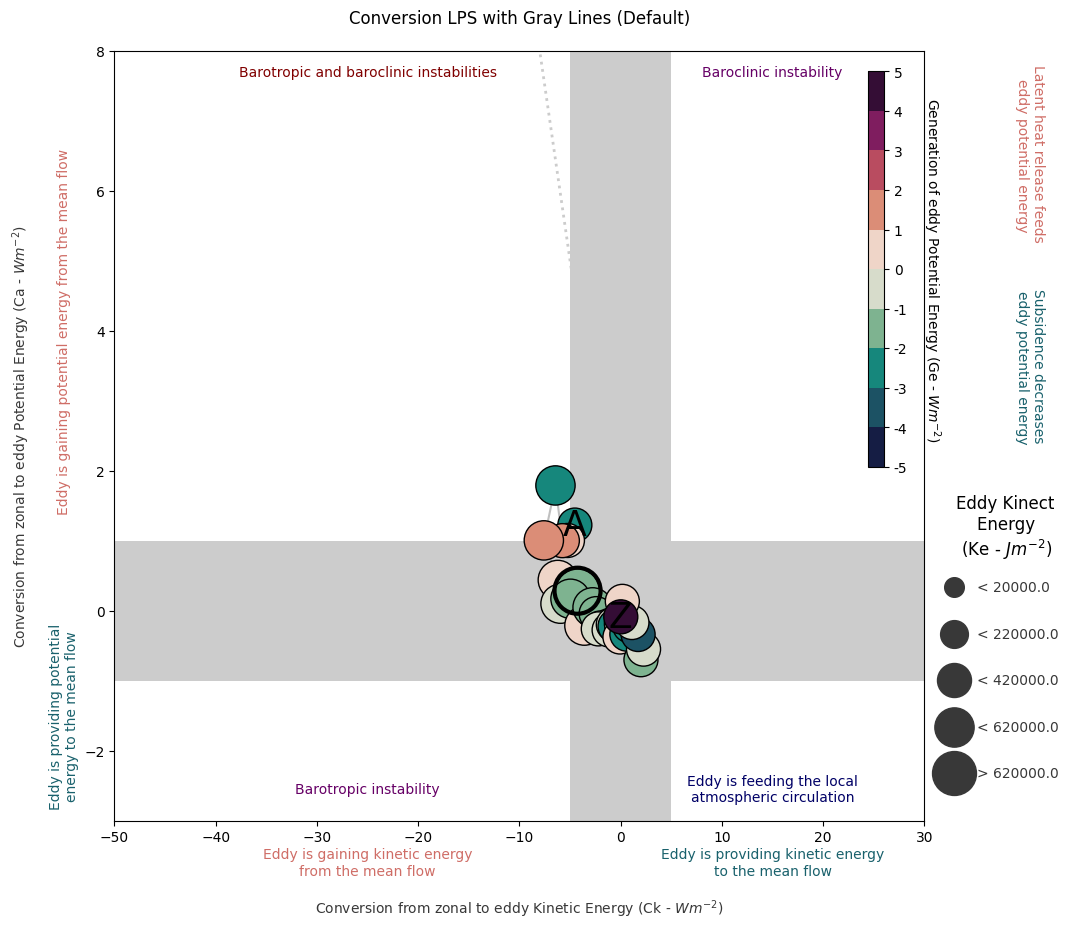

In [3]:
# Create Conversion LPS without zoom (standard mode)
lps_gray = Visualizer(LPS_type='conversion', zoom=False)

# Plot the data with gray lines (default behavior)
lps_gray.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke'],
    use_arrows=False  # Gray lines (this is the default)
)

plt.title('Conversion LPS with Gray Lines (Default)', pad=20)
plt.show()

## 2a. Plot with Gray Lines (Default)

By default, the plot uses **gray lines** to connect consecutive points, providing a clean and professional appearance:

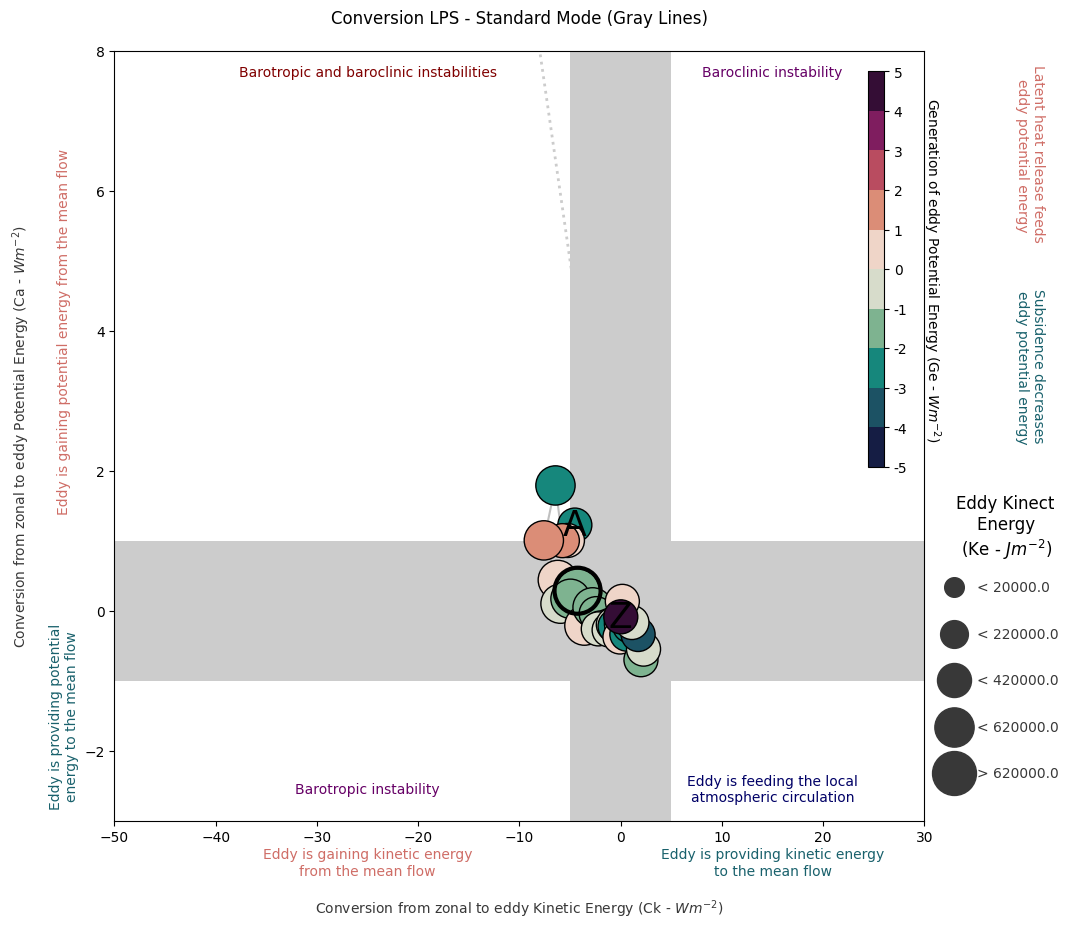

In [4]:
# Create Conversion LPS without zoom (standard mode)
lps = Visualizer(LPS_type='conversion', zoom=False)

# Plot the data (default: gray lines connecting points)
lps.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Conversion LPS - Standard Mode (Gray Lines)', pad=20)
plt.show()

### Interpretation

- **Upper-right quadrant**: Baroclinic instability (Ca+ and Ck+)
- **Upper-left quadrant**: Both baroclinic and barotropic instabilities
- **Lower-left quadrant**: Barotropic instability
- **Lower-right quadrant**: Eddy feeding local circulation
- **Red colors**: Latent heat release (positive Ge)
- **Blue colors**: Subsidence (negative Ge)
- **Marker 'A'**: Start of lifecycle
- **Marker 'Z'**: End of lifecycle

## 3b. Using Arrows Instead of Lines

You can enable arrows to show the direction of evolution:

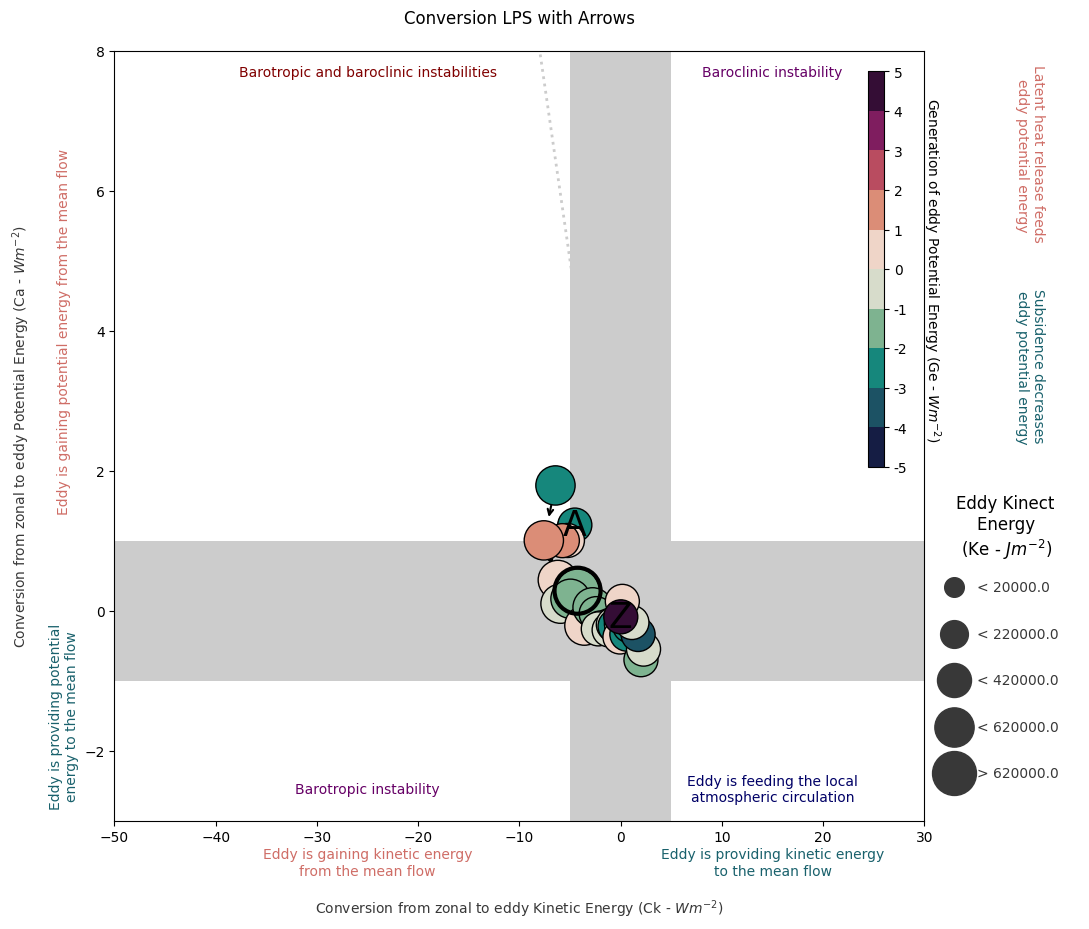

In [5]:
# Create Conversion LPS with arrows enabled
lps_arrows = Visualizer(LPS_type='conversion', zoom=False)

# Plot with arrows
lps_arrows.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke'],
    use_arrows=True  # Enable arrows
)

plt.title('Conversion LPS with Arrows', pad=20)
plt.show()

## 3c. Customizing Connection Lines

You can customize the appearance of the connection lines:

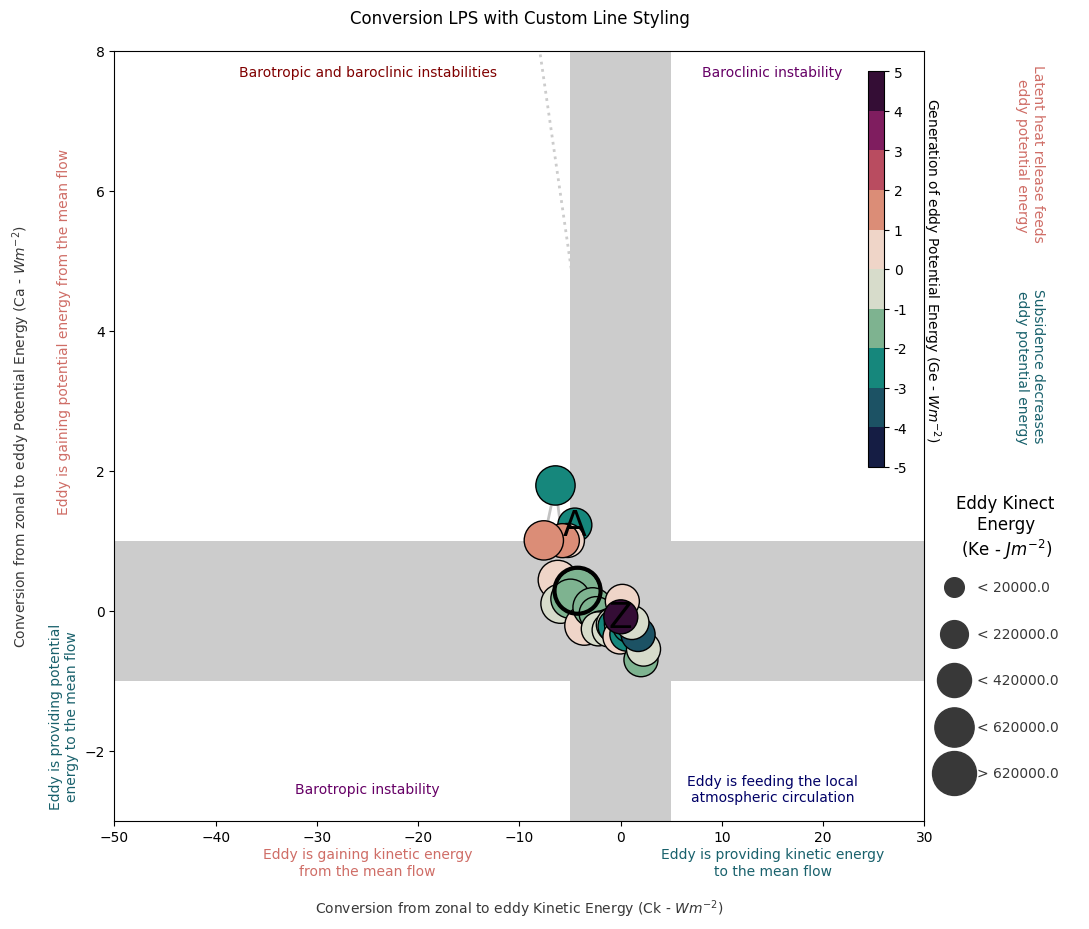

In [6]:
# Create Conversion LPS with custom line styling
lps_custom = Visualizer(LPS_type='conversion', zoom=False)

# Plot with custom gray lines
lps_custom.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke'],
    use_arrows=False,          # Use lines (default)
    connection_color='darkgray', # Custom color
    connection_alpha=0.7,      # Custom transparency
    connection_linewidth=2.0   # Custom width
)

plt.title('Conversion LPS with Custom Line Styling', pad=20)
plt.show()

## 3. Zoomed LPS Plot

For detailed analysis, use **zoom mode** which adjusts limits to your data:

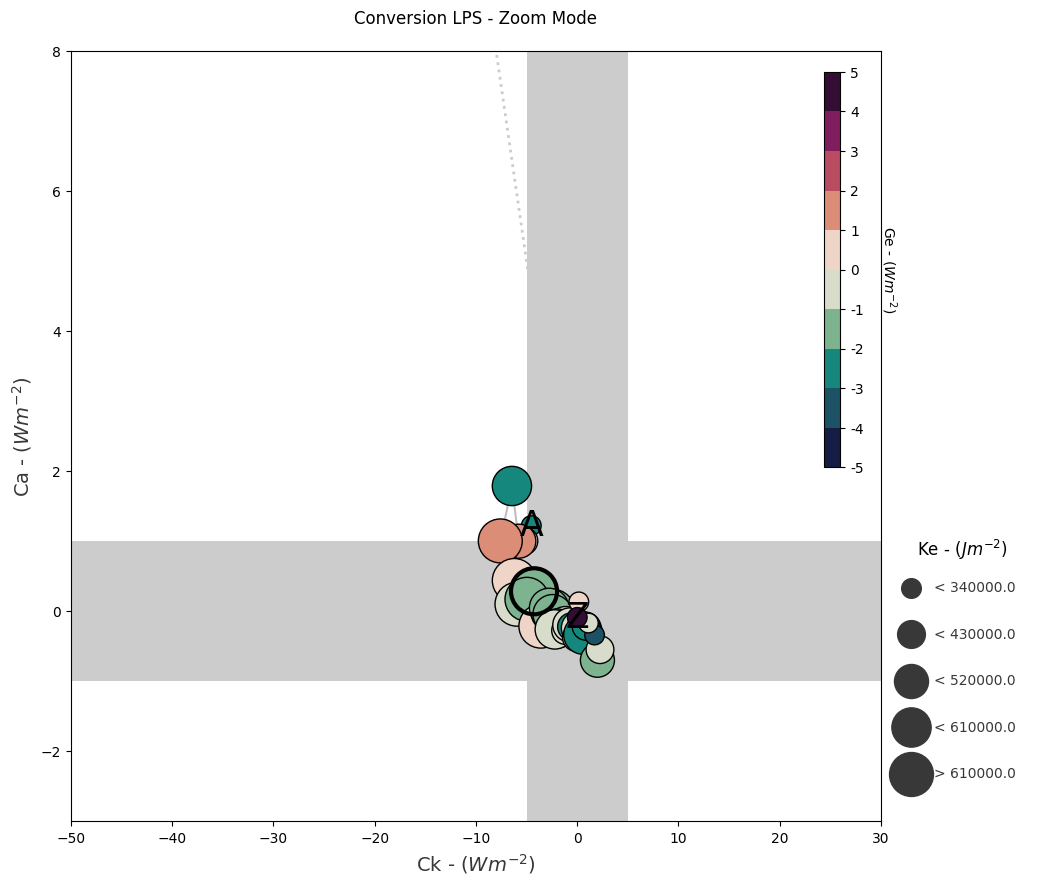

In [7]:
# Create Conversion LPS with zoom (dynamic limits)
lps_zoom = Visualizer(LPS_type='conversion', zoom=True)

# Plot the data
lps_zoom.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Conversion LPS - Zoom Mode', pad=20)
plt.show()

## 4. Comparing Multiple Cyclones

Let's create two cyclone datasets and compare them:

In [8]:
# Use the second cyclone dataset for comparison
print("Two real cyclone datasets ready for comparison")
print(f"\nCyclone 1 (Sample 1):")
print(f"  Ck range: [{data['Ck'].min():.1f}, {data['Ck'].max():.1f}]")
print(f"  Ca range: [{data['Ca'].min():.1f}, {data['Ca'].max():.1f}]")
print(f"  Date: {data['Datetime'].iloc[0].strftime('%Y-%m-%d')}")

print(f"\nCyclone 2 (Sample 2):")
print(f"  Ck range: [{data2['Ck'].min():.1f}, {data2['Ck'].max():.1f}]")
print(f"  Ca range: [{data2['Ca'].min():.1f}, {data2['Ca'].max():.1f}]")
print(f"  Date: {data2['Datetime'].iloc[0].strftime('%Y-%m-%d')}")

Two real cyclone datasets ready for comparison

Cyclone 1 (Sample 1):
  Ck range: [-7.6, 2.3]
  Ca range: [-0.7, 1.8]
  Date: 2005-08-08

Cyclone 2 (Sample 2):
  Ck range: [-55.1, 6.6]
  Ca range: [-1.2, 11.6]
  Date: 1982-10-11


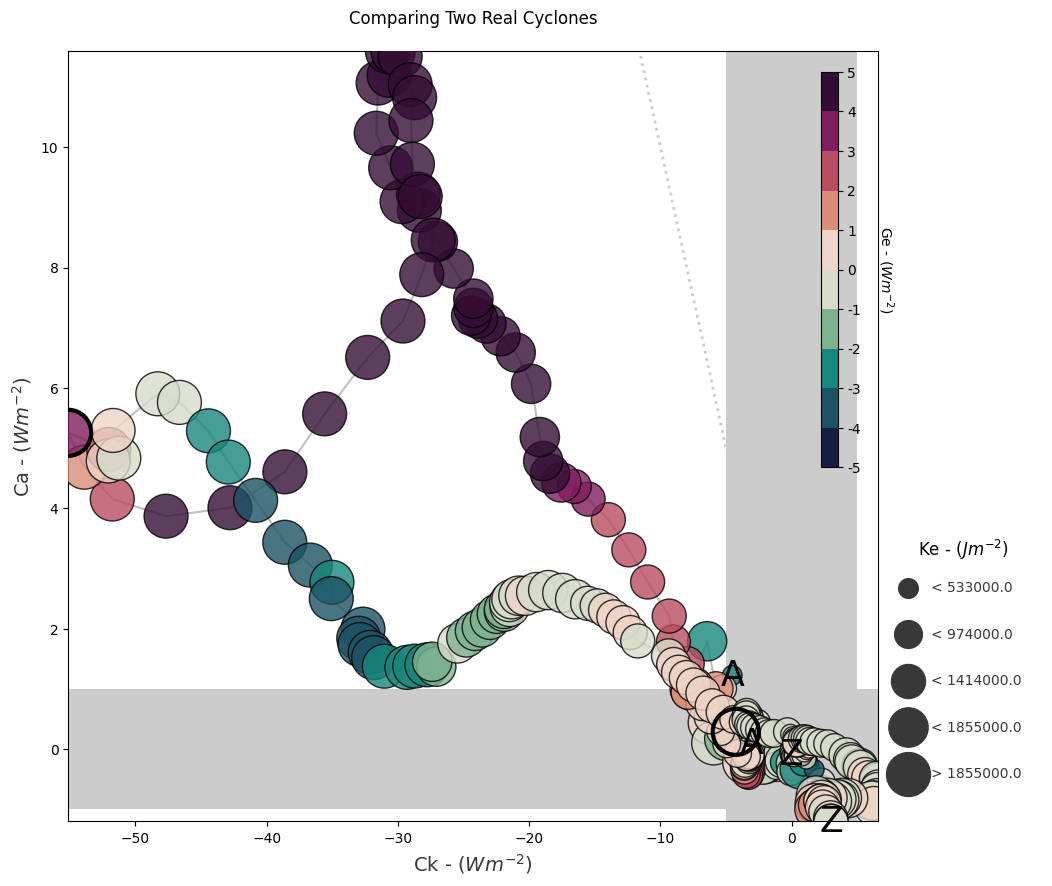

In [9]:
# Calculate common limits for fair comparison
x_min = min(data['Ck'].min(), data2['Ck'].min())
x_max = max(data['Ck'].max(), data2['Ck'].max())
y_min = min(data['Ca'].min(), data2['Ca'].min())
y_max = max(data['Ca'].max(), data2['Ca'].max())
color_min = min(data['Ge'].min(), data2['Ge'].min())
color_max = max(data['Ge'].max(), data2['Ge'].max())
size_min = min(data['Ke'].min(), data2['Ke'].min())
size_max = max(data['Ke'].max(), data2['Ke'].max())

# Create LPS with custom limits
lps_compare = Visualizer(
    LPS_type='conversion',
    zoom=True,
    x_limits=[x_min, x_max],
    y_limits=[y_min, y_max],
    color_limits=[color_min, color_max],
    marker_limits=[size_min, size_max]
)

# Plot both cyclones
lps_compare.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke'],
    alpha=0.8
)

lps_compare.plot_data(
    x_axis=data2['Ck'],
    y_axis=data2['Ca'],
    marker_color=data2['Ge'],
    marker_size=data2['Ke'],
    alpha=0.8
)

plt.title('Comparing Two Real Cyclones', pad=20)
plt.show()

## 5. Baroclinic LPS

Focus specifically on **baroclinic processes**:

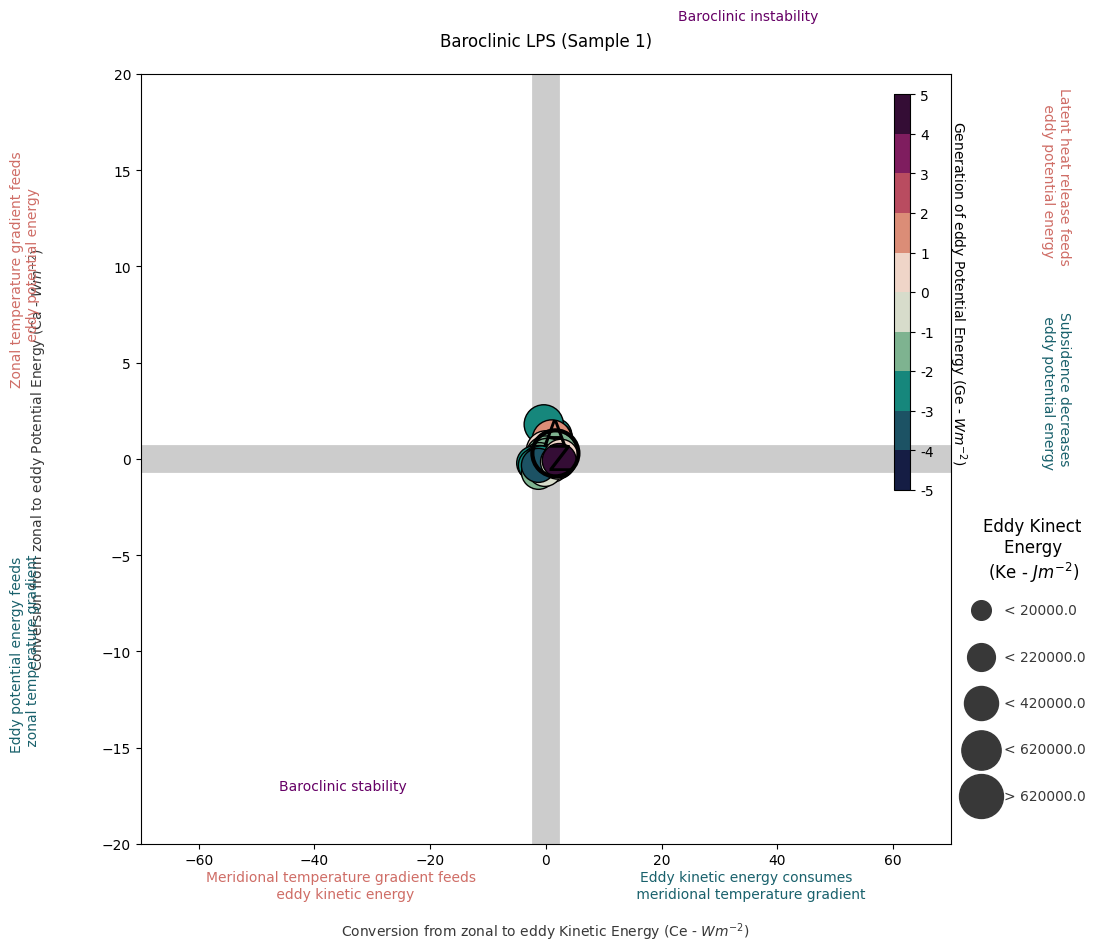

In [10]:
# Use real data for baroclinic LPS (Ce instead of Ck)
# Create Baroclinic LPS
lps_baro = Visualizer(LPS_type='baroclinic', zoom=False)

lps_baro.plot_data(
    x_axis=data['Ce'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Baroclinic LPS (Sample 1)', pad=20)
plt.show()

## 6. Imports LPS

Analyze **energy imports and exports** across boundaries:

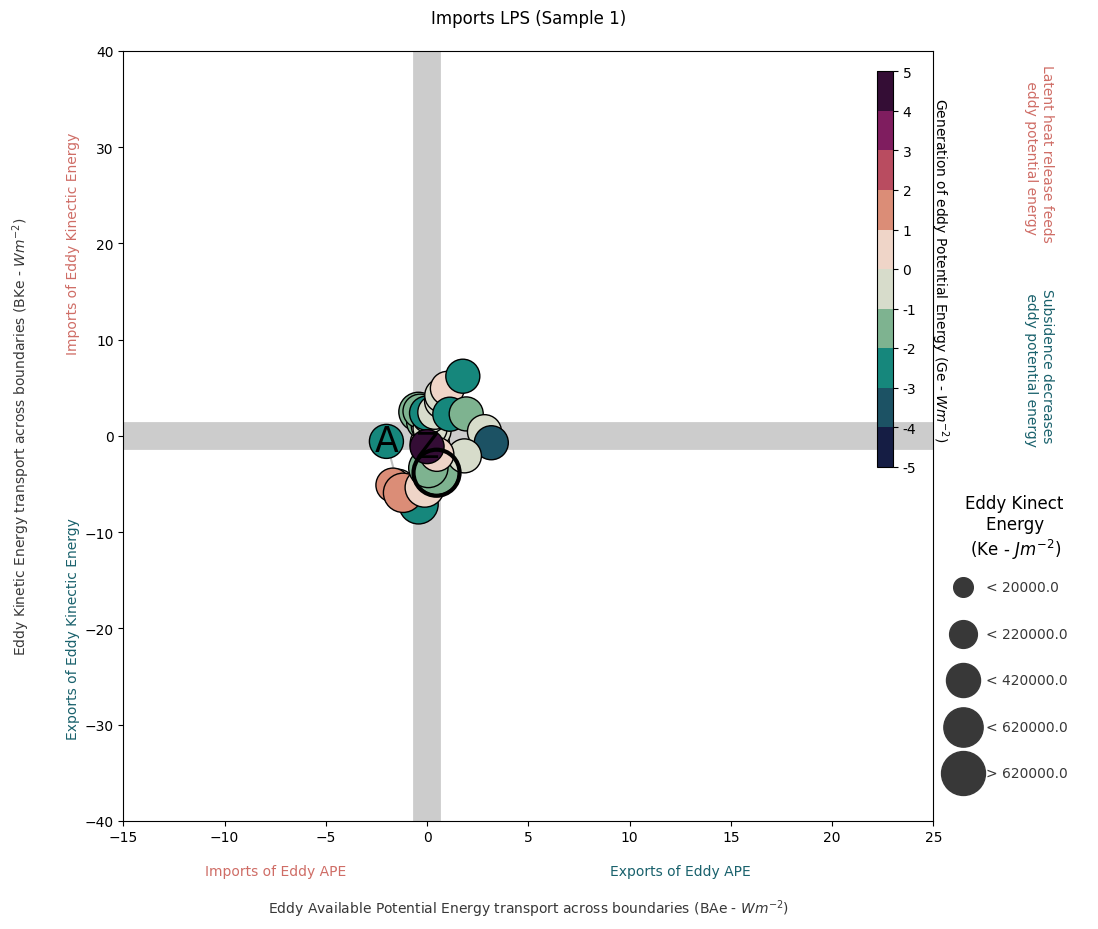

In [11]:
# Use real data for imports LPS
# Create Imports LPS
lps_imports = Visualizer(LPS_type='imports', zoom=False)

lps_imports.plot_data(
    x_axis=data['BAe'],
    y_axis=data['BKe'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Imports LPS (Sample 1)', pad=20)
plt.show()

## 7. Working with Real Data

If you have real cyclone data in a CSV file:

In [12]:
# Example: Using your own data files
# The sample files we loaded are structured like this:

print("Expected CSV structure:")
print("- Columns: Date, Hour, Ck, Ca, Ge, Ke, Ce, BAe, BKe, etc.")
print("- Date format: YYYY-MM-DD")
print("- Hour: 0, 6, 12, 18 (6-hourly data)")
print("\nFor conversion LPS, you need: Ck, Ca, Ge, Ke")
print("For baroclinic LPS, you need: Ce, Ca, Ge, Ke")
print("For imports LPS, you need: BAe, BKe, Ge, Ke")

print("\n" + "="*60)
print("To load your own data:")
print("```python")
print("your_data = pd.read_csv('path/to/your/data.csv',")
print("                        parse_dates={'Datetime': ['Date', 'Hour']},")
print("                        date_format='%Y-%m-%d %H')")
print("```")

Expected CSV structure:
- Columns: Date, Hour, Ck, Ca, Ge, Ke, Ce, BAe, BKe, etc.
- Date format: YYYY-MM-DD
- Hour: 0, 6, 12, 18 (6-hourly data)

For conversion LPS, you need: Ck, Ca, Ge, Ke
For baroclinic LPS, you need: Ce, Ca, Ge, Ke
For imports LPS, you need: BAe, BKe, Ge, Ke

To load your own data:
```python
your_data = pd.read_csv('path/to/your/data.csv',
                        parse_dates={'Datetime': ['Date', 'Hour']},
                        date_format='%Y-%m-%d %H')
```


## 8. Saving Figures

Save publication-quality figures:

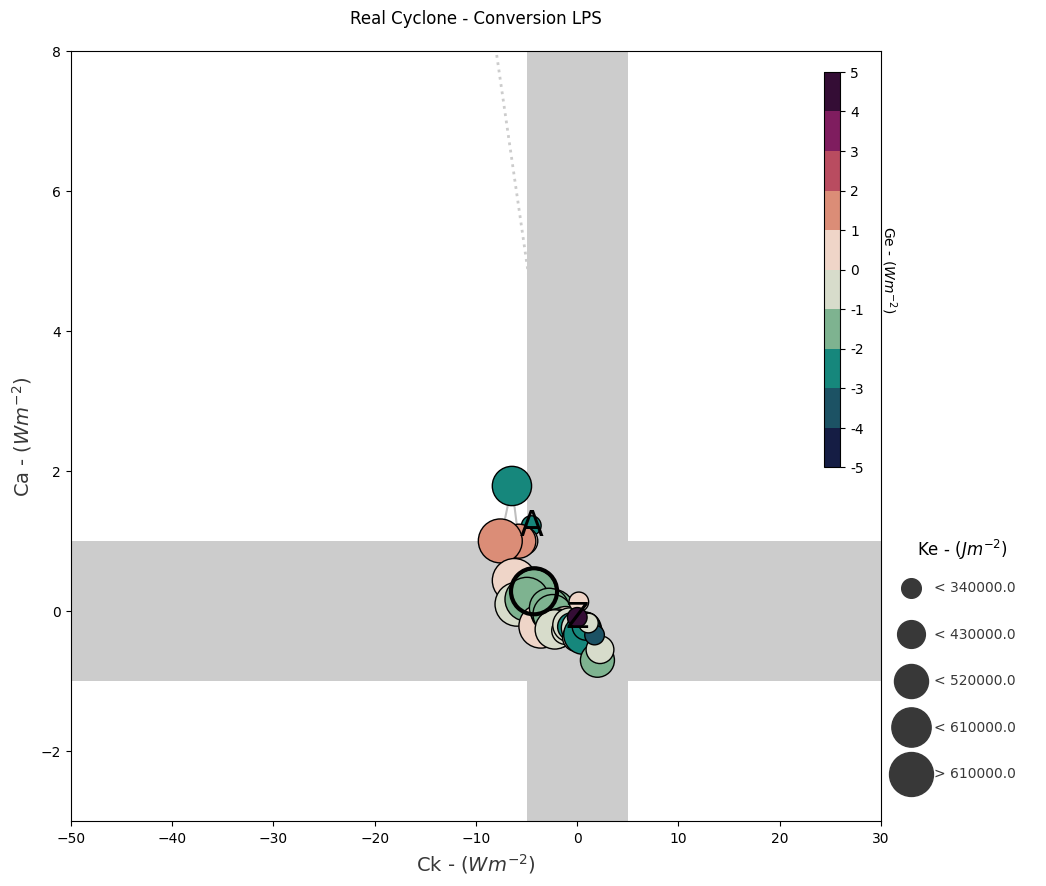


To save figures, uncomment the plt.savefig() lines above.


In [13]:
# Create a figure to save
lps_save = Visualizer(LPS_type='conversion', zoom=True)
lps_save.plot_data(
    x_axis=data['Ck'],
    y_axis=data['Ca'],
    marker_color=data['Ge'],
    marker_size=data['Ke']
)

plt.title('Real Cyclone - Conversion LPS', pad=20)

# Save in multiple formats
# plt.savefig('lps_diagram.png', dpi=300, bbox_inches='tight')
# plt.savefig('lps_diagram.pdf', bbox_inches='tight')
# plt.savefig('lps_diagram.svg', bbox_inches='tight')

plt.show()
print("\nTo save figures, uncomment the plt.savefig() lines above.")

## Summary

This notebook demonstrated:

1. ✅ Loading and using real cyclone data from sample files
2. ✅ Creating basic Conversion LPS plots (formerly "mixed")
3. ✅ Using zoom mode for detailed analysis
4. ✅ Comparing multiple cyclones with custom limits
5. ✅ Creating Baroclinic LPS plots
6. ✅ Creating Imports LPS plots
7. ✅ Using gray lines (default) and arrows for trajectory visualization
8. ✅ Customizing connection line styles
9. ✅ Saving publication-quality figures

## Key Changes in Latest Version

- **LPS Type Renamed**: "mixed" is now called "**conversion**" for better clarity
- **Updated Limits** (conversion LPS):
  - Ck: -50 to 30 (x-axis)
  - Ca: -3 to 8 (y-axis)
  - Ge: -10 to 10 with discrete colors
  - Ke: 2×10⁴ to 1×10⁶ (5 size intervals)
- **Enhanced Reference Lines**: Horizontal and vertical lines now use filled regions for better visibility
- **Improved Text Positioning**: All annotations dynamically centered in their respective quadrants

## Next Steps

- Review the [API Documentation](../docs/API_DOCUMENTATION.md) for detailed parameter descriptions
- Check the [Quick Reference](../docs/QUICK_REFERENCE.md) for common use cases
- Read the [Testing Guide](../tests/TESTING.md) to understand the test suite

## References

- Hart, R. E. (2003). A Cyclone Phase Space derived from thermal wind and thermal asymmetry. *Monthly Weather Review*, 131(4), 585-616.
- Lorenz, E. N. (1955). Available potential energy and the maintenance of the general circulation. *Tellus*, 7(2), 157-167.